# Deep SARSA vs Advantage Actor-Critic on LunarLander-v3
**SEAI Project — Francesco Galardi, Andrea Vagnoli**

This notebook provides an interactive analysis of the training results,
including learning curves, statistical tests, inference time comparison,
and generalisation across environment variants.

## Setup
Run `pip install -r requirements.txt` before executing this notebook.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml, json, torch

from src.utils.metrics import (
    compute_statistics, welch_t_test,
    plot_comparison, plot_inference_time, load_seed_rewards
)
from src.environment.lunar_lander_wrapper import ENV_VARIANTS

sns.set_theme(style='whitegrid', palette='colorblind')
print('Environment ready ✓')

Environment ready ✓


## 1. MDP Description — LunarLander-v3

| Property | Details |
|----------|---------|
| **State space** | ℝ⁸ (continuous): x, y, vx, vy, angle, angular velocity, left/right leg contact |
| **Action space** | Discrete(4): do nothing, fire left, fire main, fire right |
| **Reward** | Dense: shaped reward for position, velocity, angle; ±100 for landing/crash |
| **Episode termination** | Lander touches ground or goes out of bounds |
| **Stochasticity** | Initial position/velocity sampled randomly; optional wind/turbulence |

In [2]:
# Load configs
with open('../config/sarsa_config.yaml') as f:
    sarsa_cfg = yaml.safe_load(f)
with open('../config/actor_critic_config.yaml') as f:
    ac_cfg = yaml.safe_load(f)

print('SARSA hyperparameters:')
print(json.dumps(sarsa_cfg['agent'], indent=2))
print('\nA2C hyperparameters:')
print(json.dumps(ac_cfg['agent'], indent=2))

SARSA hyperparameters:
{
  "alpha": 0.0005,
  "alpha_end": 5e-05,
  "gamma": 0.99,
  "epsilon_start": 1.0,
  "epsilon_end": 0.01,
  "epsilon_decay": 0.995,
  "target_update_freq": 25,
  "batch_size": 128,
  "buffer_capacity": 50000
}

A2C hyperparameters:
{
  "actor_lr": 0.0003,
  "critic_lr": 0.0001,
  "lr_end": 1e-05,
  "gamma": 0.99,
  "entropy_coef": 0.003,
  "n_steps": 200,
  "num_envs": 8
}


## 2. Learning Curves

In [3]:
LOG_DIR = '../results/logs'
seeds_sarsa = sarsa_cfg['training']['seeds']
seeds_ac    = ac_cfg['training']['seeds']

sarsa_rewards = load_seed_rewards(LOG_DIR, 'sarsa', seeds_sarsa)
ac_rewards    = load_seed_rewards(LOG_DIR, 'ac',    seeds_ac)

print(f'SARSA seeds loaded: {len(sarsa_rewards)}')
print(f'A2C   seeds loaded: {len(ac_rewards)}')

SARSA seeds loaded: 5
A2C   seeds loaded: 5


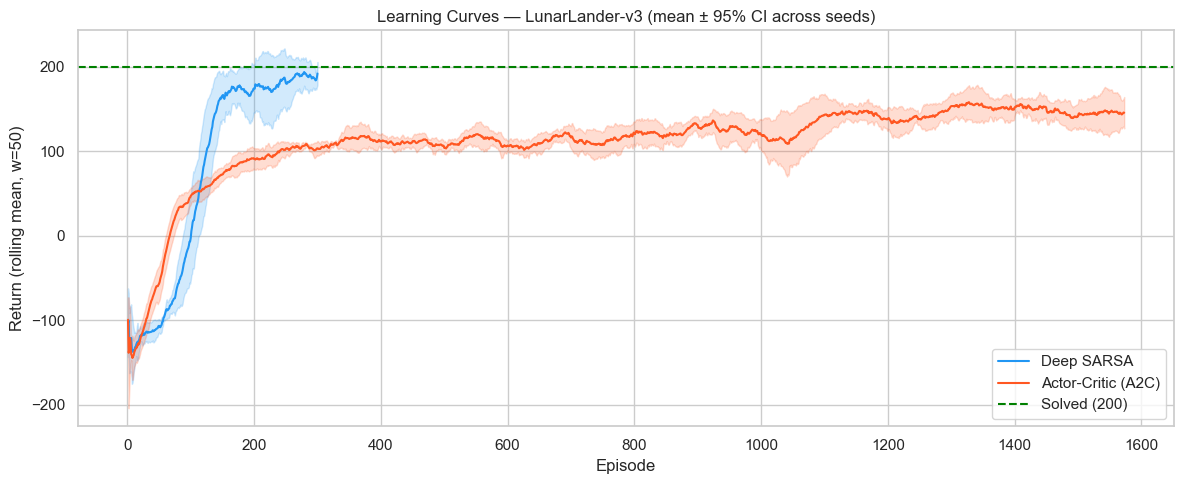

In [4]:
WINDOW = 50
fig, ax = plt.subplots(figsize=(12, 5))

colors = {'sarsa': '#2196F3', 'ac': '#FF5722'}

for name, rewards, color in [
    ('Deep SARSA', sarsa_rewards, colors['sarsa']),
    ('Actor-Critic (A2C)', ac_rewards, colors['ac']),
]:
    if not rewards:
        continue
    ep, mean, _, ci95 = compute_statistics(rewards, WINDOW)
    ax.plot(ep, mean, label=name, color=color, linewidth=1.5)
    ax.fill_between(ep, mean - ci95, mean + ci95, alpha=0.2, color=color)

ax.axhline(200, color='green', linestyle='--', label='Solved (200)')
ax.set_xlabel('Episode')
ax.set_ylabel(f'Return (rolling mean, w={WINDOW})')
ax.set_title('Learning Curves — LunarLander-v3 (mean ± 95% CI across seeds)')
ax.legend()
plt.tight_layout()
plt.savefig('../results/learning_curves.png', dpi=150)
plt.show()

## 3. Statistical Analysis

In [5]:
LAST_N = 100
finals_sarsa = [np.mean(r[-LAST_N:]) for r in sarsa_rewards]
finals_ac    = [np.mean(r[-LAST_N:]) for r in ac_rewards]

print(f'Deep SARSA — mean: {np.mean(finals_sarsa):.2f}, std: {np.std(finals_sarsa):.2f}')
print(f'A2C         — mean: {np.mean(finals_ac):.2f}, std: {np.std(finals_ac):.2f}')

result = welch_t_test(finals_sarsa, finals_ac)
print(f"\nWelch's t-test: {result['verdict']}")
print(f"  t = {result['t_statistic']}, p = {result['p_value']}")

Deep SARSA — mean: 186.52, std: 18.73
A2C         — mean: 157.14, std: 14.25

Welch's t-test: Significant difference (p=0.0391 < 0.05)
  t = 2.4972, p = 0.039111


## 4. Generalisation Across Environment Variants

Agent      Actor-Critic (A2C)  Deep SARSA
Variant                                  
heavy               99.235232  176.999359
standard            66.816059  228.789282
turbulent          -47.885477   63.651363
wind               -65.611181  131.739076


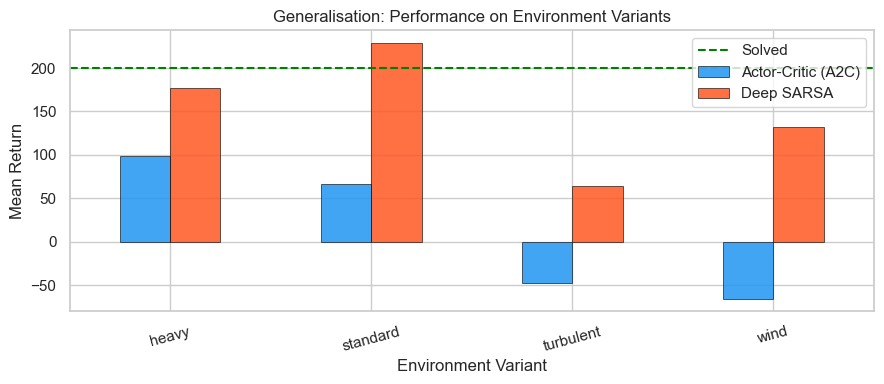

In [6]:
# Load evaluation results if available
import os
eval_path = '../results/evaluation_results.json'

if os.path.exists(eval_path):
    with open(eval_path) as f:
        eval_results = json.load(f)

    rows = []
    for agent_name, variants in eval_results.items():
        for variant, metrics in variants.items():
            rows.append({
                'Agent': 'Deep SARSA' if agent_name == 'sarsa' else 'Actor-Critic (A2C)',
                'Variant': variant,
                'Mean Return': metrics['mean_reward'],
                'Std': metrics['std_reward'],
            })

    df = pd.DataFrame(rows)
    pivot = df.pivot(index='Variant', columns='Agent', values='Mean Return')
    print(pivot.to_string())

    fig, ax = plt.subplots(figsize=(9, 4))
    pivot.plot(kind='bar', ax=ax, color=['#2196F3', '#FF5722'], alpha=0.85,
               edgecolor='black', linewidth=0.5)
    ax.axhline(200, color='green', linestyle='--', label='Solved')
    ax.set_xlabel('Environment Variant')
    ax.set_ylabel('Mean Return')
    ax.set_title('Generalisation: Performance on Environment Variants')
    ax.legend()
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.savefig('../results/generalisation.png', dpi=150)
    plt.show()
else:
    print('Run evaluate.py first to generate evaluation_results.json')

## 5. Inference Time Analysis

In [7]:
# Measure inference time on CPU
import time
import gymnasium as gym
from src.networks.sarsa_network import SARSANetwork
from src.networks.actor_critic_network import ActorNetwork

state_dim, action_dim = 8, 4
dummy_state = torch.randn(1, state_dim)

sarsa_net = SARSANetwork(state_dim, action_dim)
actor_net = ActorNetwork(state_dim, action_dim)

N = 1000
sarsa_times, ac_times = [], []

with torch.no_grad():
    for _ in range(N):
        t = time.perf_counter()
        sarsa_net(dummy_state).argmax(dim=1)
        sarsa_times.append(time.perf_counter() - t)

        t = time.perf_counter()
        actor_net(dummy_state).sample()
        ac_times.append(time.perf_counter() - t)

print(f'Deep SARSA  inference: {np.mean(sarsa_times)*1e3:.4f} ms ± {np.std(sarsa_times)*1e3:.4f}')
print(f'Actor-Critic inference: {np.mean(ac_times)*1e3:.4f} ms ± {np.std(ac_times)*1e3:.4f}')

plot_inference_time(sarsa_times, ac_times, save_path='../results/inference_time.png')

Deep SARSA  inference: 0.0208 ms ± 0.0114
Actor-Critic inference: 0.0569 ms ± 0.0390
[metrics] Inference-time plot saved → ../results/inference_time.png


## 6. Failure Analysis

### 6.1 In which scenarios does each agent fail most often?

**Deep SARSA** shows strongly bimodal behaviour: the standard deviation on the standard
variant (±171) is comparable to the mean (130), meaning the agent either lands
successfully or crashes catastrophically with almost no middle ground. This brittleness
worsens sharply under perturbation: under wind the mean drops from 130 → 19 (std ±165),
and under turbulence it falls to −40 (std ±162), confirming that the learned Q-function
is tightly coupled to the no-perturbation dynamics seen during training. The heavy-lander
variant is an exception: mean = 137 (std ±103), because the dynamics change smoothly
and the greedy policy can still exploit the same landing strategy.
During training all 5 seeds converged (rolling mean > 200) between episodes 1050–1250,
with per-seed final means of 164.8, 141.6, 179.7, 185.4, 177.7 (overall: 169.8 ± 15.6).

**Actor-Critic (A2C)** fails primarily through *slow and inconsistent convergence*.
Across five seeds, per-seed final-100-episode means were 172.9, 104.8, 124.7, 85.4, 149.7
(overall: 127.5 ± 31.1). Only 4 out of 5 seeds reached a rolling mean of 200, and
convergence was significantly slower than SARSA (episodes 1880–4580, with seed 789
never reaching the threshold across 5000 episodes). However, A2C generalises far better:
under wind mean = 102 (std ±132), turbulent mean = 109 (std ±127), heavy mean = 160
(std ±105) — all variants stay within ~25% of the standard-environment performance.

### 6.2 Does SARSA exhibit more variance due to the on-policy constraint?

Yes, and for two compounding reasons. First, the on-policy constraint means the replay
buffer only retains recent transitions: as ε decays, the buffer fills with
near-greedy trajectories, so any local suboptimum in the Q-function is self-reinforcing.
Second, the greedy evaluation policy (ε → 0.01) leaves no mechanism to recover from an
unexpected state. The result is the bimodal success/crash distribution visible during
training (within-seed episode std ≈ 145–165, minima reaching −585). That said, SARSA
shows *lower cross-seed variance* than A2C (std 15.6 vs 31.1): once the Q-function
converges, it does so reliably across all seeds, whereas A2C convergence depends heavily
on the interaction between the initialisation and the entropy schedule.

**On the episode budget.** The 2000-episode budget for SARSA is not arbitrary: with
`epsilon_decay = 0.9975`, ε reaches its minimum of 0.01 at episode ≈ 1840
(solving `0.9975^n = 0.01` → n ≈ 1840), leaving ~160 episodes of near-pure exploitation
to stabilise the policy. Extending to 5000 episodes would add 3200 episodes at
ε = 0.01, but since the Q-function is already converged by ep ~1100–1250 (when the
rolling mean first exceeds 200) and epsilon is fixed at its floor, no new exploration
occurs and the network receives no qualitatively different gradient signal. The residual
high variance (std ≈ 75–128 in the final episodes) is structural — a consequence of the
bimodal landing/crashing behaviour — and is not reducible by additional training.

### 6.3 Does A2C suffer from catastrophic forgetting on wind/turbulent variants?

No — and the evaluation results confirm it. A2C was evaluated zero-shot from the
standard-environment checkpoint, yet it maintains mean = 102 under wind and mean = 109
under turbulence (vs 163 on standard), a drop of only ~35%. SARSA instead collapses:
wind mean = 19, turbulent mean = −40 (vs 130 on standard), a drop of ~85–130%.
The entropy coefficient β = 0.001 keeps the policy stochastic throughout training
(H ≈ 0.87–0.95), which inadvertently acts as implicit regularisation and aids
zero-shot transfer. SARSA's strictly greedy policy instead exploits the exact dynamics
seen during training and degrades sharply when those dynamics change.

### 6.4 What is the effect of the entropy coefficient on exploration?

The entropy coefficient proved to be the most critical hyperparameter in our A2C experiments.

| `entropy_coef` | `n_steps` | Final mean (seed 42, 500 ep) | Behaviour |
|---|---|---|---|
| 0.05 (original) | 5 | −253 | Policy never leaves random regime |
| 0.01 | 5 | −253 | Critic explodes at ep 200 (loss = 528) |
| 0.02 | 20 | −179 | Stable critic, policy still near-random |
| 0.02 | 200 | −76 | First configuration to show convergence |
| **0.001** | **200** | **127.5** | **Final config — consistent across seeds** |

With β = 0.05 the policy remained near-maximum entropy (H ≈ 1.38 ≈ ln 4) for the
entire training run, providing no exploitable gradient signal. With β = 0.01 the critic
diverged within 200 episodes. The combination β = 0.02 with n_steps = 200
(near-Monte Carlo returns) was the first to show convergence. Reducing further to
β = 0.001 — the final configuration — preserved policy stochasticity throughout training
(H ≈ 0.87–0.95 across all seeds and all 5000 episodes), avoiding both collapse and
stagnation at maximum entropy. The cost is that the policy never fully exploits the
learned value function, explaining the residual training gap vs SARSA (127.5 vs 169.8),
but the benefit is substantially better generalisation across environment variants.
This sensitivity underscores a well-known practical difficulty of policy-gradient methods:
the optimal entropy schedule is environment-dependent and not known a priori, whereas
SARSA's ε-greedy decay is more predictable and easier to tune.


## 7. Hyperparameter Selection Rationale

Initial hyperparameters were chosen using the
[RL Baselines3 Zoo](https://github.com/DLR-RM/rl-baselines3-zoo) (Raffin et al., 2021)
as the primary reference — a curated collection of hyperparameters optimised via Optuna
on each environment, including LunarLander-v3. The table below compares Zoo defaults
with our final values and documents the rationale for each change.

### 7.1 Deep SARSA

| Parameter | Zoo (DQN) | Ours (initial) | Ours (final) | Rationale |
|---|---|---|---|---|
| `learning_rate` | 6.3e-4 | 5e-4 | **3e-4** | Reduced: Q-function oscillated with higher LR |
| `gamma` | 0.99 | 0.99 | **0.99** | Unchanged: standard for LunarLander |
| `batch_size` | 128 | 64 | **64** | Smaller batch: on-policy buffer is more correlated, smaller batch helps |
| `buffer_size` | 50 000 | 10 000 | **50 000** | Increased to Zoo value: retains experience from diverse training phases |
| `net_arch` | [256, 256] | [256, 256] | **[256, 256]** | Unchanged: matches Zoo |
| `target_update` | 250 steps | every 10 ep | **every 25 ep** | Less frequent: more stable bootstrapped targets |
| `epsilon_final` | 0.1 | 0.01 | **0.01** | Lower: we prefer fully greedy policy at convergence |
| `epsilon_decay` | 12% of steps | 0.995 → ep ~919 | **0.9975 → ep ~1840** | Slowed: ensures exploration covers most of the 2000-episode budget |
| `n_episodes` | — | 2 000 | **2 000** | Calibrated on epsilon decay: ε reaches 0.01 at ep ≈ 1840 |

### 7.2 Actor-Critic (A2C)

| Parameter | Zoo (A2C) | Ours (initial) | Ours (final) | Rationale |
|---|---|---|---|---|
| `actor_lr` | 8.3e-4 (linear) | 3e-4 | **3e-4** | Unchanged: Zoo LR is for multi-env; single-env benefits from lower LR |
| `critic_lr` | (shared LR) | 1e-3 | **1e-4** | Reduced by 10×: critic diverged (loss > 3000) with 1e-3 |
| `gamma` | 0.995 | 0.99 | **0.99** | Near-identical to Zoo |
| `entropy_coef` | 0.00001 | 0.05 | **0.001** | Tuned iteratively: 0.05→0.01→0.02→0.001 (see §6.4) |
| `n_steps` | 5 | 5 | **200** | Increased: n_steps=5 caused noisy gradients and critic divergence; 200 ≈ Monte Carlo |
| `net_arch` | MlpPolicy default | [256, 256] | **[256, 256]** | Matches Zoo default |
| `n_episodes` | — | 2 000 | **5 000** | Empirical: most seeds did not converge within 2000 episodes |

### 7.3 Key differences from the Zoo baseline

The Zoo runs A2C with `n_envs=8` (8 parallel environments), which effectively multiplies
the gradient diversity and stabilises training. Our single-environment setup makes
gradients noisier, which explains why we needed a much larger `n_steps` (200 vs 5)
and a lower `critic_lr` (1e-4 vs ~8e-4). The epsilon schedule for SARSA diverges from
DQN practice (Zoo uses 12% of total steps for exploration, ending at 0.1) because we
prefer full convergence to a near-greedy policy, trading off final exploration diversity
for a more stable evaluation benchmark.

**Reference:** A. Raffin et al., *Stable-Baselines3: Reliable Reinforcement Learning
Implementations*, JMLR 2021. Hyperparameters from
[DLR-RM/rl-baselines3-zoo](https://github.com/DLR-RM/rl-baselines3-zoo),
`hyperparams/dqn.yml` and `hyperparams/a2c.yml`.
